# Inpainting with GPR-LIM

June, 2026

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import glob
import sys

import gprlim
from gprlim import kernels

from pyuvdata import UVData
import bayeslim as ba

In [2]:
torch.set_default_dtype(torch.float64)

In [3]:
sys.path.append('../')
import gp_utils

In [4]:
import gpytorch
gpytorch.settings.max_cholesky_size._set_value(1_000)

In [5]:
torch.set_default_dtype(torch.float64)
device = 'cpu'

# load the meta-data

The data is of shape (Nbaseline, Ntimes, Nfrequencies, Npolarizations) -> (Nbls, Ntimes, Nfreq, Npol).

The data is complex.

Each "baseline" is formed between two antennas, so a baseline index is often denoted as (ant1, ant2).

Frequencies are in Hz, times are in Julian Date (which is just in days). LST is local sidereal time in radians. Polarization is the polarization state of the electric field, which comes in dual linear polarization state (XX, YY, XY, YX). We also call this (EE, NN, EN, NE) for east and north.

The simulation contains two things:
1. a simulation of the "foregrounds" including the synchrotron emission from the Milky Way galactic disk, and the radio galaxy point source background.

2. a simulation of a mock EoR 21cm field. 

so y = fg + eor for "sum".

The "sum.uvh5" has the two summed together. The "eor.uvh5" has just the EoR simulation. We will generate the noise ourselves in the notebook (using this formalism `hera_cal.noise.predict_noise_variance_from_autos`). 


The simulation has 1600 time integrations and 600 frequency bins, and 243 unique baseline vectors.

We call the data the "visibility" which we also sometimes call the "cross-correlation visibility" i.e. the cross-correlation between two antennas. The visibility of an antenna with itself (e.g. 0, 0) we call the "auto-correlation" visibility.

We observe at MHz frequencies (120 - 190 MHz).

The data are in units of Jansky (Jy).

In [145]:
# specify frequency channels
# by default, use equal to or less than 200 time integrations
# by default, use about 300-400 frequency channels
freq_chans = range(200, 600)
time_ints = range(300, 500)

In [127]:
# specify data
dfile = '../zen.h6c_idr2_validation.sum.uvh5'
#dfile = sorted(glob.glob('../zen.h6c_idr2_validation.24582*.sum.coupled.h5'))

In [128]:
# load autocorrelation and metadata
vd, meta = gp_utils.load_uvdata(
    dfile, bls=[(0, 0)], pols=['ee'], time_ints=time_ints, freq_chans=freq_chans,
)
autocorr = vd.data[0,0]

# get antenna information
antp = meta['antp']
ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

# get baseline information
red_bls = meta['bls']
all_pols = meta['pols']
reds = meta['reds']

# get noise standard deviation
noise_amp = autocorr.real / np.sqrt(np.diff(meta['times'])[0]*24*3600 * np.diff(meta['freqs'])[0])

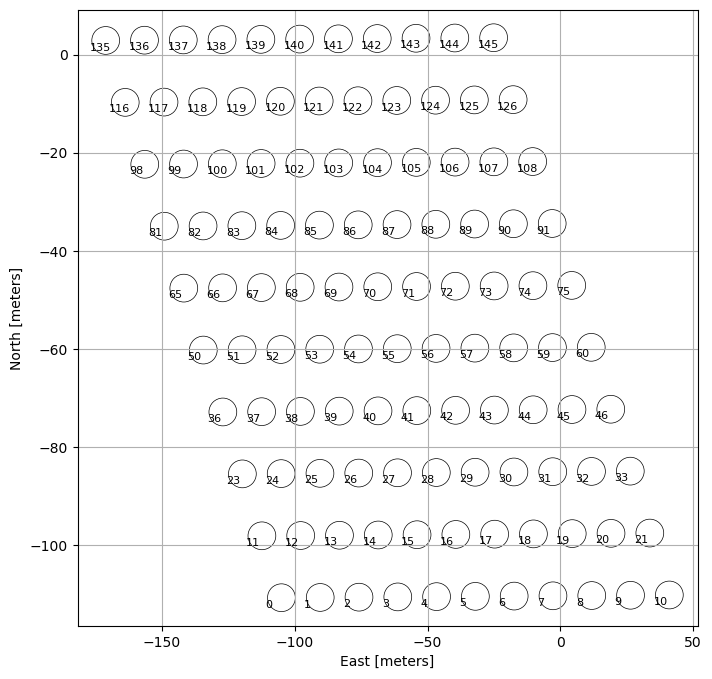

In [129]:
plt.figure(figsize=(8,8))
plt.scatter(*antpos[:, :2].T, fc='none', ec='k', s=400, lw=.5)
for i, a in enumerate(ants):
    plt.text(antpos[i,0]-6, antpos[i,1]-2, a, fontsize=8)
plt.xlabel('East [meters]'); plt.ylabel('North [meters]'); plt.grid();

# load redundant data

load a single redundant baseline

In [146]:
# pick a representative baseline to load and model (start with 0)
bl = (0, 2)

# this gets the index in the redundant set that this baseline falls in
red_ind = np.where([bl in red for red in reds])[0][0]
bls = reds[red_ind][:]
bl_vec = antp[bls[0][1]] - antp[bls[0][0]]
bl_len = bl_vec.norm()

In [147]:
# load single baseline data
vd, meta = gp_utils.load_uvdata(
    dfile,
    bls=bls,
    time_ints=time_ints,
    freq_chans=freq_chans,
    pols=['ee'],
    device=device,
)
freqs = meta['freqs'] / 1e6
lsts = meta['lsts']
times = (meta['times'] - meta['times'][0]) * 24 * 3600
Ntimes = len(times)
Nfreqs = len(freqs)
reds = meta['reds']

Antenna pair (1, 3) does not have any data associated with it.
Antenna pair (2, 4) does not have any data associated with it.
Antenna pair (3, 5) does not have any data associated with it.
Antenna pair (4, 6) does not have any data associated with it.
Antenna pair (5, 7) does not have any data associated with it.
Antenna pair (6, 8) does not have any data associated with it.
Antenna pair (7, 9) does not have any data associated with it.
Antenna pair (8, 10) does not have any data associated with it.
Antenna pair (11, 13) does not have any data associated with it.
Antenna pair (12, 14) does not have any data associated with it.
Antenna pair (13, 15) does not have any data associated with it.
Antenna pair (14, 16) does not have any data associated with it.
Antenna pair (15, 17) does not have any data associated with it.
Antenna pair (16, 18) does not have any data associated with it.
Antenna pair (17, 19) does not have any data associated with it.
Antenna pair (18, 20) does not have any 

In [148]:
inflate_data = True
if inflate_data and vd.Nbls == 1:
    vd = vd.inflate_by_redundancy(bls=reds[red_ind])

In [149]:
add_noise = False
if add_noise:
    vd.data += torch.randn_like(vd.data) * noise_amp * 1e-3

In [150]:
# look at how large the data is
print("size of data in MB: {:.1f}".format(vd.data.nbytes/1e6))

size of data in MB: 115.2


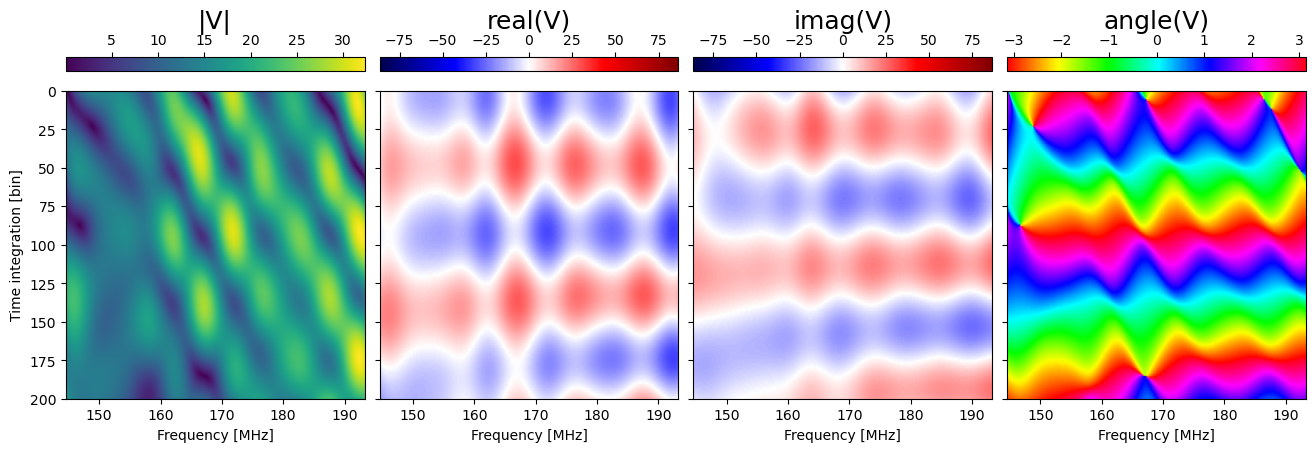

In [151]:
# plot the data (called a waterfall)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.subplots_adjust(wspace=.05)
dstd = vd.data.std()

# visibility amplitude (abs)
cax = axes[0].imshow(vd.data[0,0,0].abs(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[0].set_title("|V|", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[0], location='top');
axes[0].set_xlabel('Frequency [MHz]'); axes[0].set_ylabel('Time integration [bin]');

# visibility real
cax = axes[1].imshow(vd.data[0,0,0].real, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='seismic',
                     vmin=-dstd*5, vmax=dstd*5)
axes[1].set_title("real(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[1], location='top');
axes[1].set_xlabel('Frequency [MHz]'); axes[1].set_yticklabels([])

# visibility imag
cax = axes[2].imshow(vd.data[0,0,0].imag, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='seismic',
                     vmin=-dstd*5, vmax=dstd*5)
axes[2].set_title("imag(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[2], location='top');
axes[2].set_xlabel('Frequency [MHz]'); axes[2].set_yticklabels([]);

# visibility phase
cax = axes[3].imshow(vd.data[0,0,0].angle(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='hsv')
axes[3].set_title("angle(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[3], location='top');
axes[3].set_xlabel('Frequency [MHz]'); axes[3].set_yticklabels([]);

# define flags

A few different flag types

1. Narrow frequency, full time

2. Wide frequency, full time

3. Ultra-wide frequency, short time

4. Narrow frequency, short time

5. Full band frequency, short time

6. Narrow frequency, intermittent time

In [208]:
flag_types = [
    'real',
    'narrowband_full_time',
    #'wideband_full_time',
    #'ultraband_short_time',
    #'fullband_short_time',
    #'narrowband_short_time',
    #'narrowband_intermittent',
]

flags = torch.zeros((1, Ntimes, Nfreqs), dtype=torch.bool)

if 'real' in flag_types:
    # load flags
    flg = np.load('../zen.h6c_idr3.2459951.flag_waterfall_round2.npz')['flags'][time_ints][:, freq_chans, 0]
    flg = torch.as_tensor(flg, device=device)
    flags = flags + flg
    
if 'narrowband_full_time' in flag_types:
    # 1 channel wide, all times
    torch.manual_seed(100)
    rand = torch.randint(low=0, high=Nfreqs, size=(15,))
    flags[:, :, rand] = True
    
    
if 'wideband_full_time' in flag_types:
    # 10-20 channels wide, all times
    torch.manual_seed(101)
    
    
if 'ultraband_short_time' in flag_types:
    # 20-30 wide, 1-4 time integrations
    torch.manual_seed(102)

    
if 'fullband_short_time' in flag_types:
    # all channels wide, 1-3 time integrations
    torch.manual_seed(104)

    
if 'narrowband_short_time' in flag_types:
    # 1-3 channels wide, 3-10 time integrations
    torch.manual_seed(103)

    
if 'narrowband_intermittent' in flag_types:
    # 1-3 channels wide, 75 time integrations
    torch.manual_seed(105)
    


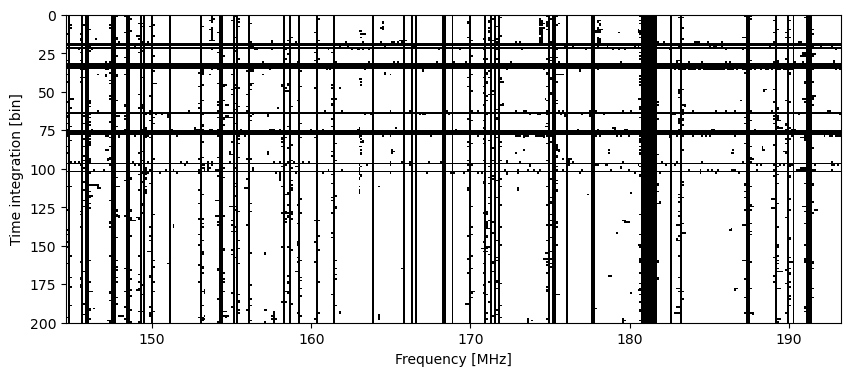

In [212]:
plt.figure(figsize=(10, 4))
plt.imshow(flags[0],
           cmap='Greys', aspect='auto', interpolation='none', extent=[freqs[0], freqs[-1], Ntimes, 0]
)
plt.xlabel('Frequency [MHz]'); plt.ylabel('Time integration [bin]');

In [155]:
from bayeslim.fft import FFT

# 1D FT across frequency
FT1 = FFT(dim=-1, N=vd.data.shape[-1], ndim=2, window='bh', dx=(freqs[1]-freqs[0])/1e3)

# 1D FT across time
FT2 = FFT(dim=-2, N=vd.data.shape[-2], ndim=2, window='bh', dx=(lsts[1]-lsts[0])*12/np.pi*3600/1e3)

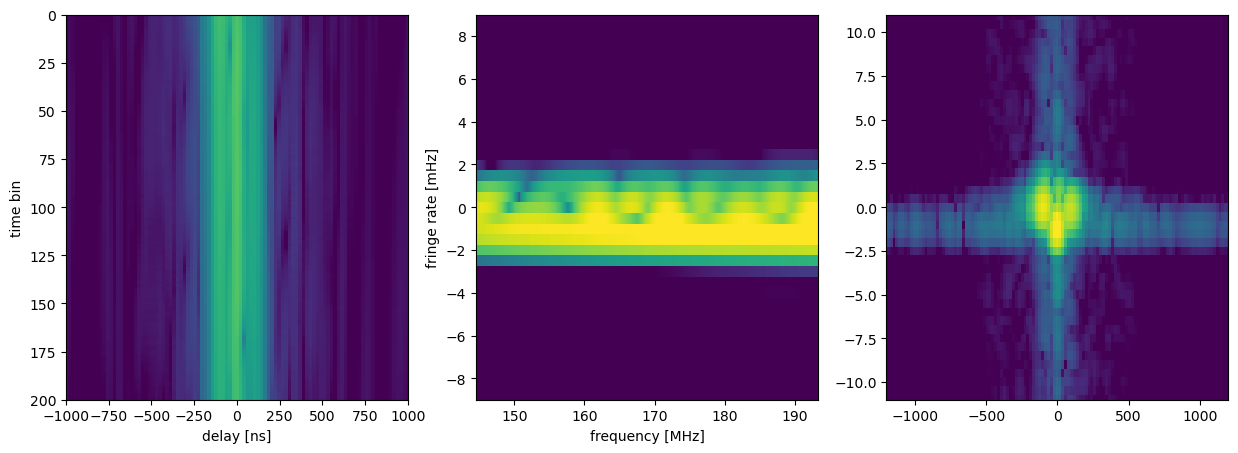

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(FT1(vd.data)[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=-1, vmax=5,
               extent=[FT1.freqs[0], FT1.freqs[-1], Ntimes, 0])
axes[0].set_xlim(-1000, 1000); axes[0].set_xlabel('delay [ns]'); axes[0].set_ylabel('time bin')

axes[1].imshow(FT2(vd.data)[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=0, vmax=3,
               extent=[freqs[0], freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[1].set_ylim(-9, 9); axes[1].set_xlabel('frequency [MHz]'); axes[1].set_ylabel('fringe rate [mHz]')

axes[2].imshow(FT1(FT2(vd.data))[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=-1, vmax=5,
               extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[2].set_xlim(-1200, 1200); axes[2].set_ylim(-11, 11);

# now do GPR inpainting

Choose a time covariance. A few different modes to select from.

1. A top-hat kernel spanning all fringe-rate modes of the visibility
2. A custom profile

### specify the time kernel

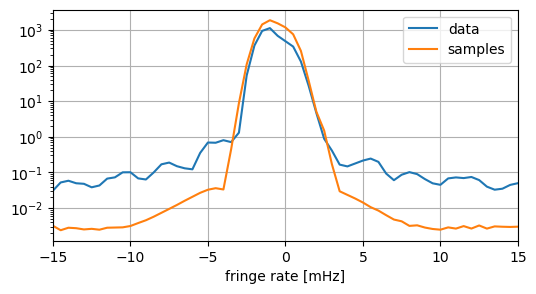

In [157]:
#### ['tophat', 'custom']
kernel_type = 'custom'

default_buf = 1.0
default_min_hw = 0.5

if kernel_type == 'tophat':
    
    time_kernel = gprlim.kernels.default_time_kernel(
        freqs*1e6, bl_vec, meta['lat'], ml_scale=2e0, fz_scale=1e-3, fr_scale=1e3,
        buffer=default_buf, min_hw=default_min_hw, only_global_amp=True,
    )
    
elif kernel_type == 'custom':
    
    time_kernel = gprlim.kernels.default_time_kernel(
        freqs*1e6, bl_vec, meta['lat'], ml_scale=1e3, fz_scale=3e-1, fr_scale=1e-4,
        buffer=default_buf, min_hw=default_min_hw, only_global_amp=True,
    )
     

# draw samples from the time covariance: increase jitter if not positive definite
samples = gprlim.models.prior_draws_1d(time_kernel, times, size=100, jitter=1e-10)

# plot the covariance samples against the data
plt.figure(figsize=(6, 3))
plt.plot(FT2.freqs, FT2(vd.data)[0,0,0].abs().mean(1), label='data')
plt.plot(FT2.freqs, FT2(samples.T).abs().mean(1), label='samples');
plt.xlim(-15, 15); plt.xlabel('fringe rate [mHz]'); plt.legend(); plt.yscale('log'); plt.grid()

### specify the frequency kernel

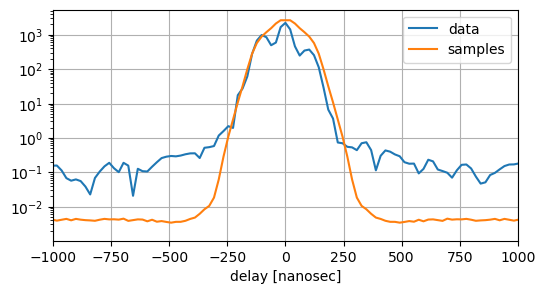

In [163]:
# ['tophat', 'custom']
kernel_type = 'custom'

default_buffer = 100.0
default_min_delay = 50.0

if kernel_type == 'tophat':
    
    freq_kernel = gprlim.kernels.default_freq_kernel(
        bl_vec, only_global_amp=True, ml_scale=3e0, pf_scale=1e0, wd_scale=1e0, lk_scale=1e3,
        real=True, buffer=default_buffer, min_delay=default_min_delay,
    )
    
elif kernel_type == 'custom':
    
    freq_kernel = gprlim.kernels.default_freq_kernel(
        bl_vec, only_global_amp=True, ml_scale=1e3, pf_scale=1e-1, wd_scale=1e-3, lk_scale=1e-3, 
        real=True, lk_kern='twinrbf', buffer=default_buffer, min_delay=default_min_delay, 
    )

# draw samples from the freq covariance: increase jitter if not positive definite
samples = gprlim.models.prior_draws_1d(freq_kernel, freqs, size=100, jitter=1e-10)

# plot the covariance samples against the data
plt.figure(figsize=(6, 3))
plt.plot(FT1.freqs, FT1(vd.data)[0,0,0].abs().mean(0), label='data')
plt.plot(FT1.freqs, FT1(samples).abs().mean(0), label='samples');
plt.xlim(-1000, 1000); plt.xlabel('delay [nanosec]'); plt.legend(); plt.yscale('log'); plt.grid()

# now do the inpainting

In [141]:
%%time
# assign flagged channels large variance
inv_wgts = torch.ones_like(flags, dtype=torch.float64) * 1e-3
inv_wgts[flags] = 1e3

# 1D inpaint along frequency
inp_y, mdl = gp_utils.inpaint_freq_1d(
    vd, flags, freq_kernel, inv_wgts, method='woodbury', rcond=1e-12
)

# store the inpainted data
vd_inp = vd.copy(copydata=True)
vd_inp.data = inp_y[None, None]

CPU times: user 52.5 ms, sys: 60.1 ms, total: 113 ms
Wall time: 44.1 ms


In [ ]:
%%time
# assign flagged channels large variance
inv_wgts = torch.ones_like(flags, dtype=torch.float64) * 1e-3
inv_wgts[flags] = 1e3

# 1D inpaint along time, then 1D inpaint along frequency
inp_y, mdl = gp_utils.inpaint_time_freq_1d(
    vd, flags, time_kernel, freq_kernel, inv_wgts, method='woodbury', rcond=1e-12, noise_mult=100,
)

# store the inpainted data
vd_inp = vd.copy(copydata=True)
vd_inp.data = inp_y[None, None]

In [ ]:
%%time
# assign flagged channels large variance
inv_wgts = torch.ones_like(flags, dtype=torch.float64) * 1e-3
inv_wgts[flags] = 1e3

# 2D inpaint along time and frequency simultaneously
inp_y, mdl = gp_utils.inpaint_time_freq_2d(
    vd, flags, time_kernel, freq_kernel, inv_wgts, method='cg', cg_tol=1e-3, n_threads=8,
)

# store the inpainted data
vd_inp = vd.copy(copydata=True)
vd_inp.data = inp_y[None, None]

In [ ]:
%%time
# assign flagged channels large variance
inv_wgts = torch.ones_like(flags, dtype=torch.float64) * 1e-3
inv_wgts[flags] = 1e3

# 2D inpaint along time and frequency simultaneously, then 1D freq inpaint
inp_y, mdl = gp_utils.inpaint_time_freq_2d_freq_1d(
    vd, flags, time_kernel, freq_kernel, inv_wgts, cg_tol=1e-3, rcond=1e-12, n_threads=8, noise_mult=100,
)

# store the inpainted data
vd_inp = vd.copy(copydata=True)
vd_inp.data = inp_y[None, None]

# now average the data and plot

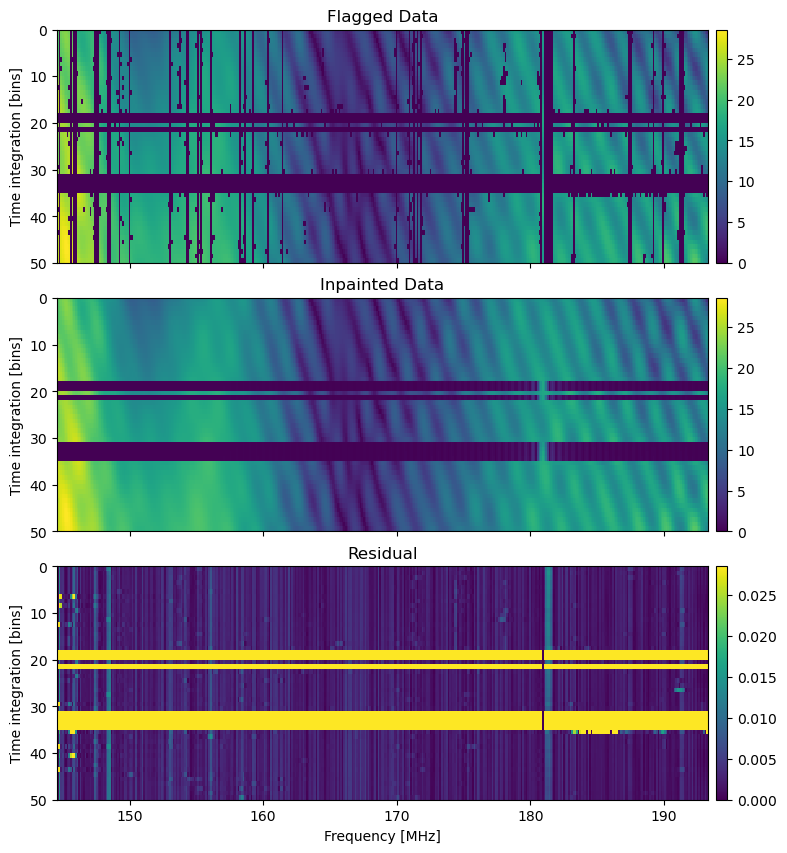

In [142]:
# plot the single baseline inpainted solution
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
fig.subplots_adjust(hspace=.15)
dmax = vd.data[0,0,0].abs().max()

cax = axes[0].imshow((vd.data[0,0,0]*~flags[0]).abs(), aspect='auto', interpolation='none', vmin=0, vmax=dmax,
               extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[0].set_xticklabels([]); axes[0].set_ylabel('Time integration [bins]')
axes[0].set_title('Flagged Data')
fig.colorbar(cax, ax=axes[0], pad=.01)

cax = axes[1].imshow(inp_y[0].abs(), aspect='auto', interpolation='none', vmin=0, vmax=dmax,
               extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[1].set_xticklabels([]); axes[1].set_ylabel('Time integration [bins]')
axes[1].set_title('Inpainted Data')
fig.colorbar(cax, ax=axes[1], pad=.01)

cax = axes[2].imshow((vd.data[0,0,0]-mdl[0]).abs(), aspect='auto', interpolation='none', vmin=0, vmax=dmax/1000,
               extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[2].set_xlabel('Frequency [MHz]'); axes[2].set_ylabel('Time integration [bins]')
axes[2].set_title('Residual');
fig.colorbar(cax, ax=axes[2], pad=.01);

In [143]:
# coherent time average the data
avg_times = ba.utils.split_into_groups(torch.arange(Ntimes), Nelem=50)
vd_avg = vd.time_average(avg_times, rephase=True, inplace=False)
vd_flg_avg = vd.time_average(avg_times, wgts=1/(flags*1e5 + 1e0), rephase=True, inplace=False)
vd_inp_avg = vd_inp.time_average(avg_times, rephase=True, inplace=False)

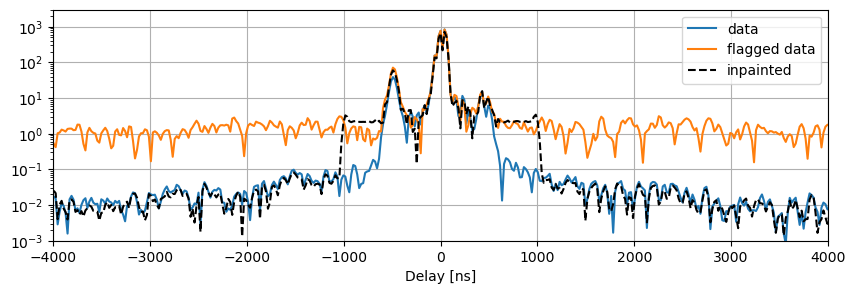

In [144]:
plt.figure(figsize=(10, 3))
plt.plot(FT1.freqs,  FT1(vd_avg.data[0,0].mean(0))[:].abs().mean(0), label='data')
plt.plot(FT1.freqs,  FT1(vd_flg_avg.data[0,0].mean(0))[:].abs().mean(0), label='flagged data')
plt.plot(FT1.freqs,  FT1(vd_inp_avg.data[0,0].mean(0))[:].abs().mean(0), c='k', ls='--', label='inpainted')
plt.yscale('log'); plt.grid(); plt.xlim(-4000, 4000); plt.ylim(1e-3, 3e3); plt.legend()
plt.xlabel('Delay [ns]');

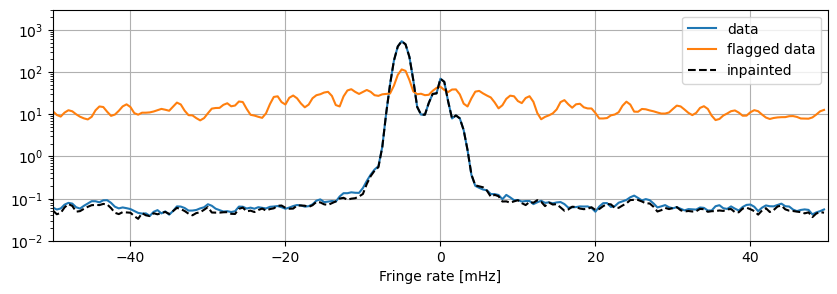

In [116]:
plt.figure(figsize=(10, 3))
plt.plot(FT2.freqs,  FT2(vd.data[0,0].mean(0))[:].abs().mean(1), label='data')
plt.plot(FT2.freqs,  FT2((flags*vd.data[0,0]).mean(0))[:].abs().mean(1), label='flagged data')
plt.plot(FT2.freqs,  FT2(inp_y.mean(0))[:].abs().mean(1), c='k', ls='--', label='inpainted')
plt.yscale('log'); plt.grid(); plt.xlim(-50, 50); plt.ylim(1e-2, 3e3); plt.legend()
plt.xlabel('Fringe rate [mHz]');

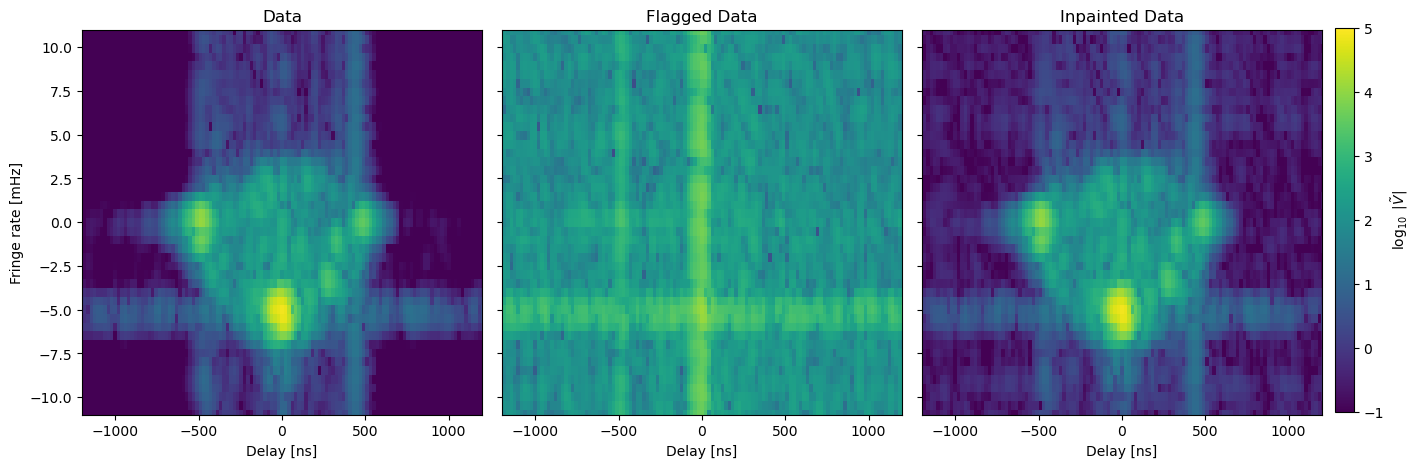

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.subplots_adjust(wspace=.05)

axes[0].imshow(FT1(FT2(vd.data[0,0].mean(0))).abs().log10(), aspect='auto', interpolation='none',
               vmin=-1, vmax=5, extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[0].set_xlim(-1200, 1200); axes[0].set_ylim(-11, 11); axes[0].set_title('Data')
axes[0].set_xlabel('Delay [ns]'); axes[0].set_ylabel('Fringe rate [mHz]')

axes[1].imshow(FT1(FT2((flags*vd.data[0,0]).mean(0))).abs().log10(), aspect='auto', interpolation='none',
               vmin=-1, vmax=5, extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[1].set_xlim(-1200, 1200); axes[1].set_ylim(-11, 11); axes[1].set_title('Flagged Data')
axes[1].set_xlabel('Delay [ns]'); axes[1].set_yticklabels([]);

cax = axes[2].imshow(FT1(FT2(inp_y.mean(0))).abs().log10(), aspect='auto', interpolation='none',
               vmin=-1, vmax=5, extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[2].set_xlim(-1200, 1200); axes[2].set_ylim(-11, 11); axes[2].set_title('Inpainted Data')
axes[2].set_xlabel('Delay [ns]'); axes[2].set_yticklabels([]);

cbax = fig.add_axes([0.84, 0.1, .08, .8]); cbax.axis('off')
cbar = fig.colorbar(cax, ax=cbax); cbar.set_label(r'$\log_{10}\ |\tilde{V}|$')

# plot other metrics?

Like the average delay spectrum power for |delay| > 1000 ns?
